In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/sample_data/train_data.csv'
data = pd.read_csv(file_path)

In [ ]:
columns_to_drop = ['Age_30-35', 'Age_35-40', 'Age_40-45', 'Age_45-50']
data_cleaned = data.drop(columns=columns_to_drop, errors='ignore')
X = data_cleaned.drop('Suicide attempt_Yes', axis=1)
y = data_cleaned['Suicide attempt_Yes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

NameError: name 'train_test_split' is not defined

In [ ]:
rf = RandomForestClassifier(random_state=42)
sfs = SequentialFeatureSelector(rf, n_features_to_select=9, direction='forward')  # Pilih 9 fitur terbaik
sfs.fit(X_train, y_train)

SequentialFeatureSelector(estimator=RandomForestClassifier(random_state=42),
                          n_features_to_select=9)

In [ ]:
selected_features = X.columns[sfs.get_support()]
X_train_sfs = X_train[selected_features]
X_test_sfs = X_test[selected_features]

selected_features = X.columns[sfs.get_support()]
print("Fitur yang dipilih:", list(selected_features))

Fitur yang dipilih: ['Feeling sad or Tearful_Sometimes', 'Irritable towards baby & partner_Sometimes', 'Irritable towards baby & partner_Yes', 'Trouble sleeping at night_Yes', 'Problems concentrating or making decision_Often', 'Overeating or loss of appetite_Not at all', 'Overeating or loss of appetite_Yes', 'Feeling anxious_Yes', 'Suicide attempt_Not interested to say']


In [ ]:
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                               n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)
rf_random.fit(X_train_sfs, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40, 50],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, verbose=2)

In [ ]:
print("Best Parameters:", rf_random.best_params_)
print("Best Score (CV):", rf_random.best_score_)

Best Parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 40}
Best Score (CV): 0.887031859006948


In [ ]:
y_pred = rf_random.best_estimator_.predict(X_test_sfs)

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       252
           1       0.85      0.83      0.84       109

    accuracy                           0.90       361
   macro avg       0.89      0.88      0.88       361
weighted avg       0.90      0.90      0.90       361



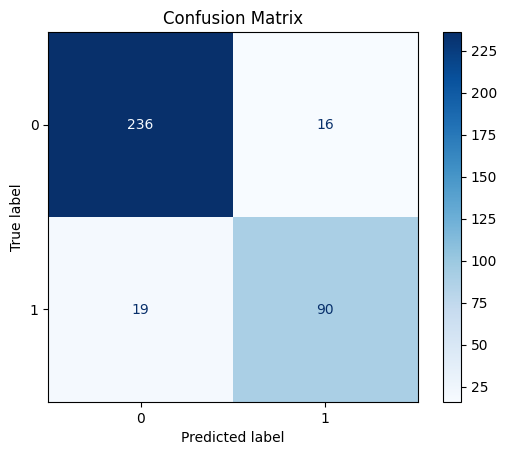

Akurasi Keseluruhan: 0.90
Fitur yang dipilih: ['Feeling sad or Tearful_Sometimes', 'Irritable towards baby & partner_Sometimes', 'Irritable towards baby & partner_Yes', 'Trouble sleeping at night_Yes', 'Problems concentrating or making decision_Often', 'Overeating or loss of appetite_Not at all', 'Overeating or loss of appetite_Yes', 'Feeling anxious_Yes', 'Suicide attempt_Not interested to say']


In [ ]:
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# b. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_random.best_estimator_.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# c. Akurasi Keseluruhan
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan: {accuracy:.2f}")

# d. Menampilkan fitur yang dipilih
print("Fitur yang dipilih:", list(selected_features))

Tabel Feature Importance Random Forest:
                                 Faktor Psikologis  Feature Importance
8            Suicide attempt_Not interested to say            0.188418
4  Problems concentrating or making decision_Often            0.147683
2             Irritable towards baby & partner_Yes            0.142804
3                    Trouble sleeping at night_Yes            0.122189
0                 Feeling sad or Tearful_Sometimes            0.085193
5        Overeating or loss of appetite_Not at all            0.084011
7                              Feeling anxious_Yes            0.083532
6               Overeating or loss of appetite_Yes            0.076390
1       Irritable towards baby & partner_Sometimes            0.069778


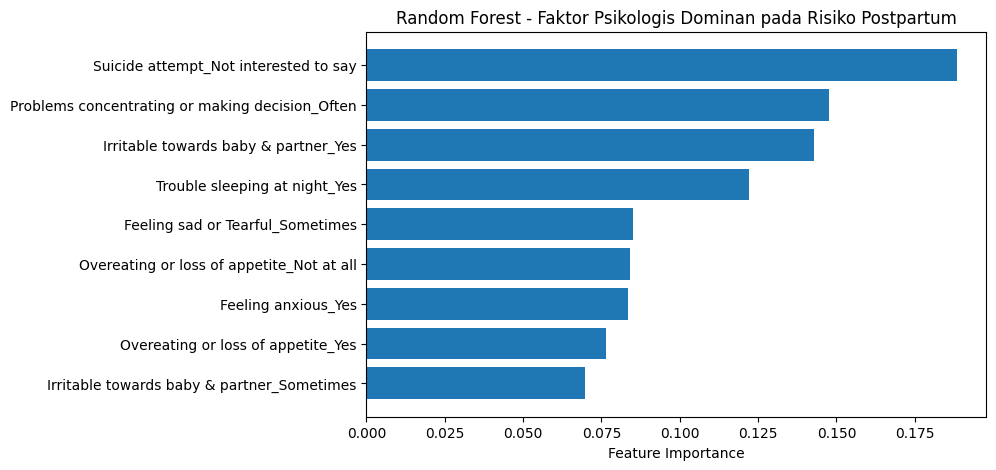

In [ ]:
importances = rf_random.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    "Faktor Psikologis": selected_features,
    "Feature Importance": importances
}).sort_values(by="Feature Importance", ascending=False)

print("Tabel Feature Importance Random Forest:")
print(feature_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df["Faktor Psikologis"], feature_importance_df["Feature Importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest - Faktor Psikologis Dominan pada Risiko Postpartum")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
test_file_path = '/content/sample_data/test_data.csv'
test_data = pd.read_csv(test_file_path)

In [ ]:
test_data_cleaned = test_data.drop(columns=columns_to_drop, errors='ignore')  # Hapus kolom yang sama seperti data latih
X_test_final = test_data_cleaned[selected_features]  # Pilih hanya fitur yang dipilih
y_test_final = test_data_cleaned['Suicide attempt_Yes']  # Asumsi target tetap sama

In [ ]:
# Prediksi pada data uji
y_test_pred = rf_random.best_estimator_.predict(X_test_final)

In [ ]:
print("Laporan Klasifikasi (Data Uji):")
print(classification_report(y_test_final, y_test_pred))

Laporan Klasifikasi (Data Uji):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       206
           1       0.87      0.79      0.83        95

    accuracy                           0.90       301
   macro avg       0.89      0.87      0.88       301
weighted avg       0.90      0.90      0.90       301



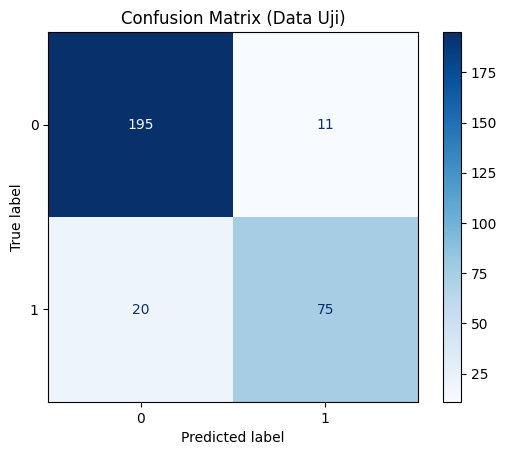

In [ ]:
cm_test = confusion_matrix(y_test_final, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=rf_random.best_estimator_.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Data Uji)")
plt.show()

In [ ]:
test_accuracy = accuracy_score(y_test_final, y_test_pred)
print(f"Akurasi Keseluruhan (Data Uji): {test_accuracy:.2f}")

Akurasi Keseluruhan (Data Uji): 0.90


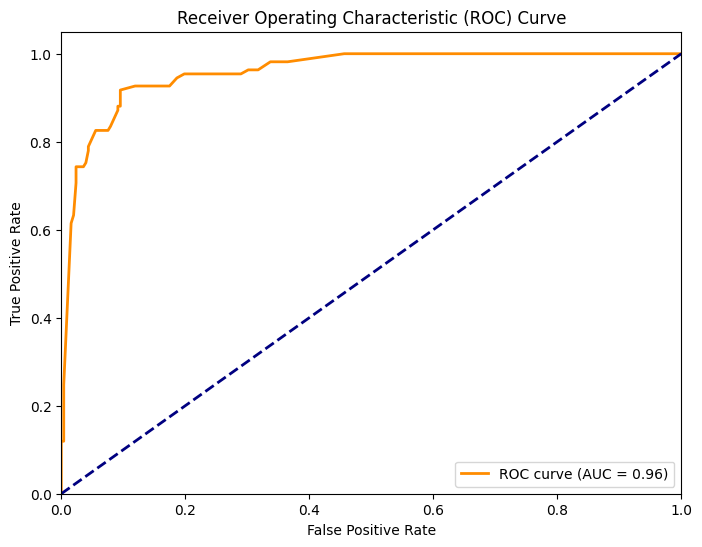

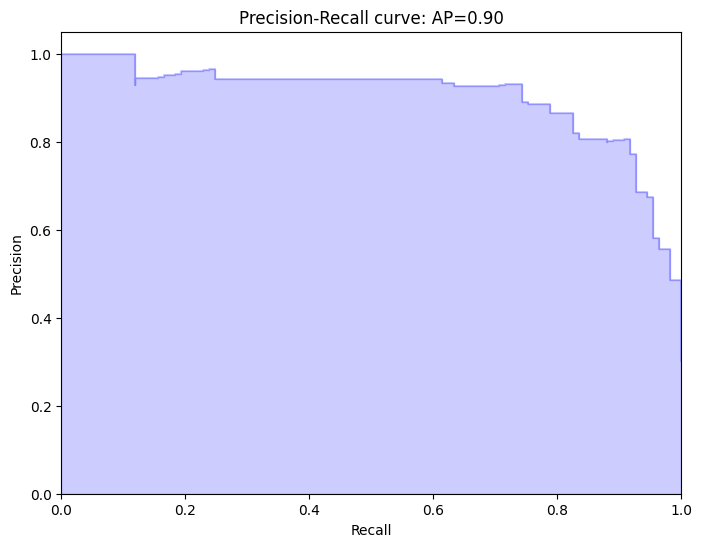

In [ ]:
y_pred_proba = rf_random.best_estimator_.predict_proba(X_test_sfs)[:, 1]
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Precision-Recall curve: AP={average_precision:.2f}')
plt.show()